## 회고

- 배운점:
    - 3채널 이미지에는 컬러맵이 필요없다는 걸 배웠다.
    - docstring 작성에 익숙해졌다. 
    - DCGAN의 가이드라인을 참고해서 아키텍처 구조와 채널 수 변화에 대해 조금 더 이해를 높인 것 같다. 
    - 풀링 대신 스트라이드 합성곱을 사용해 다운샘플링을 할 수도 있다는 걸 배웠다.
    - 낯선 몇 가지 하이퍼파라미터와 기능에 대해 익혔다. 
- 아쉬운점:
    - 훈련 시간이 길어서 다양하게 튜닝해보지 못한 것
    - 기록과 학습에 치중하다보니 시간 내에 50 에포크를 달성하지 못함
- 느낀점:
    - GIF 제작이 재밌다.
    - 실시간으로 학습과정을 확인할 수 있어서 신기하다.
- 어려웠던점: 
    - 이미지데이터의 처리할 때 훈련과 시각화 각 단계에 정규화하는 방식은 모델과 데이터셋에 따라 조금씩 다른 것 같고, 여전히 조금 복잡하게 느껴지는 것 같다.

In [1]:
import os
import glob
import time
import PIL
import imageio
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline

print("tensorflow", tf.__version__)
print(imageio.__version__)

tensorflow 2.6.0
2.9.0


In [2]:
cifar10 = tf.keras.datasets.cifar10
(train_x, _),(test_x, _) = cifar10.load_data()
train_x.shape

170508288/170498071 [==============================] - 4s 0us/step


(50000, 32, 32, 3)

In [ ]:
'''
! 참고용 코드
- 학습 시간이 너무 오래 걸릴 경우 
- 데이터셋 로드시 한 종류의 데이터만 추출하기

def load_data(label=None):
    (train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar10.load_data()
    if label:
        df = pd.DataFrame(list(zip(train_x, train_y)), columns=['image', 'label']) 
        df = df[df['label']==label]
        train_x = np.array([i for i in list(df['image'])])
        df = pd.DataFrame(list(zip(test_x, test_y)), columns =['image', 'label']) 
        df = df[df['label']==label]
        test_x = np.array([i for i in list(df['image'])])
    return train_x, test_x
'''

In [3]:
print("max pixel:", train_x.max())
print("min pixel:", train_x.min())

max pixel: 255
min pixel: 0


픽셀을 -1,1로 정규화 하기. 
중간값을 0으로 맞추기 위해 255의 중간값인 127.5를 뺀 후 127.5로 나눈다.

In [4]:
train_x = (train_x/127.5)-1

In [5]:
train_x.shape

(50000, 32, 32, 3)

In [6]:
print("max pixel:", train_x.max())
print("min pixel:", train_x.min())

max pixel: 1.0
min pixel: -1.0


첫번째 데이터(인덱스0번)를 꺼내보자

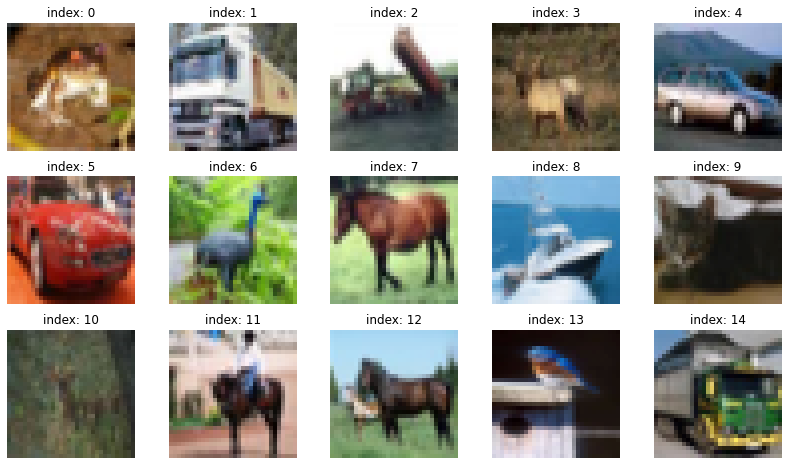

In [41]:
# RGB이미지에는 cmap이 적용되지 않음 
# 딥러닝 프레임워크는 channel-first 사용 (채널,높이,너비)
# Matplotlib, OpenCV등의 이미지 표시 라이브러리는 channel-last 사용 (높이,너비,채널)

plt. figure(figsize=(14,8))

for i in range(15):
    plt.subplot(3,5,i+1)
    # 시각화를 위해 -1 ~ 1 범위를 0 ~ 1 범위로 변환
    plt.imshow((train_x[i].reshape(32,32,3)+1)/2.0) 
    plt.title(f'index: {i}')
    plt.axis('off')

plt.show()

In [42]:
# 전체 데이터를 섞기 위해 50000으로 설정한다.
# shuffle() 함수가 데이터셋을 잘 섞어서 모델에 넣어줄 것
BUFFER_SIZE = 50000

# batch_size는 모델이 한 번에 학습할 데이터의 양
# 너무 많은 양을 한 번에 학습시키면 메모리 활용 면에서 비효율적이고 시간이 오래 걸린다.
# 미니 배치 학습: 적절한 사이즈로 잘라서 학습을 진행하는 방식
BATCH_SIZE = 256

In [43]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

tf.data.Dataset 모듈의 from_tensor_slices() 함수를 사용하면 리스트, 넘파이, 또는 텐서 자료형에서 데이터셋을 만들 수 있다. 

위 코드는 train_x라는 넘파이 배열형 자료를 섞고, 이를 배치 사이즈에 따라 나눈다. 
데이터가 잘 섞이게 하기 위해서 버퍼 사이즈를 총 데이터 사이즈와 같거나 크게 설정하는 것이 좋다. 

## DCGAN 실습

### 생성자

생성자 모델은 충분히 작은 공간 크기로 시작해서 저차원의 노이즈 벡터(예: 100차원)에 맵핑하고, 합성곱 레이어를 통한 점진적인 업샘플링 구조를 구현해야 함

DCGAN 논문에서 제안된 가이드라인을 참고: 

1. 초기 공간 크기 선택: 최종 출력 이미지 크기(32x32)로 바로 확장하지 않고, 작은 공간 차원(4x4)에서 시작하는 이유는 점진적 업샘플링을 통해 이미지의 구조를 단계적으로 생성하기 위함

2. 업샘플링 배수 계산:

    - 최종 이미지 크기: 32x32
    - 시작 크기: 4x4
    - 필요한 업샘플링: 4 → 8 → 16 → 32 (총 3번의 2배 업샘플링)

3. 채널 수(256)의 선택:

    - 많은 필터(256개)로 시작하고 점점 줄여나가는 방식(256 → 128 → 64 → 32 → 3)을 사용
    - 이는 생성자가 처음에는 추상적인 고수준 특성을 다루다가 점차 구체적인 시각적 패턴으로 변환해 나가는 과정을 모델링하기 위함
    - 초기에 많은 채널을 사용함으로써 더 풍부한 표현력을 갖게 하는 것
    
모델 설명:
1. CIFAR-10 데이터셋의 32x32 컬러 이미지를 생성하는 DCGAN 모델.
2. 100차원 노이즈 벡터를 입력으로 받는다.
3. Conv2DTranspose 레이어를 사용하여 점진적으로 이미지 크기를 키워나간다.
4. 각 레이어 이후에 배치 정규화와 LeakyReLU 활성화 함수 적용.
5. 최종 출력 레이어에는 tanh 활성화 함수로 -1과 1 사이의 픽셀 값을 생성.
6. 출력 이미지 픽셀은 -1에서 1 사이의 값을 가지므로, 시각화하기 전에 0~1 범위로 정규화하는 과정이 필요하다. 

LeakyReLU:
- 일반적인 ReLU: 양수 입력은 그대로 통과, 음수 입력만 0으로 만든다.이때 학습 과정에서 항상 0을 출력하는 "죽은 뉴런"문제 발생가능
- LeakyReLU: 음수 입력을 완전히 0으로 만들지 않고, 작은 기울기를 허용하여 죽은 뉴런 문제를 완화한다. 또한, 음수 영역에서도 그래디언트가 흐를 수 있어서 학습에 더 효과적임.

LeakyReLU의 하이퍼파라미터, alpha: 
- alpha=0.2: 음수 입력에 대해 원래 값의 20% 통과
- alpha 값은 필수값은 아니나, 여러 GAN구현에서 경험적으로 좋은 성능을 보인 하이퍼파라미터
- 일반적으로 0.01 ~ 0.3 범위의 알파값이 사용된다. 

In [52]:
# Keras Sequential API 활용
# 레이어종류()와 Sequential()은 클래스 이름이므로 대문자로 시작! 

def make_generator_model(noise_dim=100, channels=3):
    '''
    DCGAN 생성자 모델 구현 함수
    
    Args:
        noise_dim: 입력 노이즈 벡터의 차원 (기본값:100)
        channels: 출력 이미지의 채널 수 (기본값: 3, RGB 이미지)
    
    Returns:
        model: 케라스 시퀀셜 모델 객체
    '''
    # step 1: 노이즈 벡터에서 출발
    model = tf.keras.Sequential()
    
    # step 2: 완전연결레이어로 시작해서 4x4x256 크기의 특성맵으로 변환
    model.add(layers.Dense(4*4*256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # step 3: 4x4x256 텐서로 재구성
    model.add(layers.Reshape((4,4,256)))
    # assert가 하는 일: 모델이 (4,4,256) 형태로 reshape 되었는지 확인하는 코드줄!
    # 조건이 참이면 그냥 넘어간다. 
    # 조건이 거짓이면 프로그램을 중단하고 AssertionError를 발생시킨다.
    assert model.output_shape == (None, 4,4,256) # 배치사이즈 = None
    
    # step 4: 8x8x128 크기로 업샘플링
    model.add(layers.Conv2DTranspose(128, kernel_size=(4,4), strides=(2,2), padding='same',use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # step 5: 16x16x64 크기로 업샘플링
    model.add(layers.Conv2DTranspose(64, kernel_size=(4,4), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization()) 
    model.add(layers.LeakyReLU(alpha=0.2))
   
    # step 6: 32x32x32 크기로 업샘플링
    model.add(layers.Conv2DTranspose(32, kernel_size=(4,4), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization()) 
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # step 6: 최종 출력 레이어 - 32x32x32 RGB 이미지 생성
    # Conv2DTranspose 레이어의 첫번째 인자: 출력 필터의 개수(출력 이미지의 채널 수)
    model.add(layers.Conv2DTranspose(channels, kernel_size=(4,4), strides=(1,1),padding='same',use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 32,32,3)
    return model

In [46]:
# 생성모델을 generator 변수로 생성하고 세부 내용 출력
generator = make_generator_model()

generator.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              409600    
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 4096)              0         
_________________________________________________________________
reshape (Reshape)            (None, 4, 4, 256)         0         
_________________________________________________________________
conv2d_transpose (Conv2DTran (None, 8, 8, 128)         524288    
_________________________________________________________________
batch_normalization_1 (Batch (None, 8, 8, 128)         512       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 8, 8, 128)         0

### 랜덤 노이즈 생성

tf.random.normal 을 이용해 가우시안 분포에서 뽑아낸 랜덤 벡터로 이루어진 노이즈 벡터를 만들 수 있다. 

In [47]:
noise = tf.random.normal([1,100])

텐서플로우 2.0 이후 버전에서는 레이어와 모델에 call 메소드를 구현해 놓기 때문에, 방금 만들어진 생성자 모델에 입력값으로 노이즈를 넣고 바로 모델을 호출하면 간단히 결과 이미지가 생성된다. 

단, 학습 중이 아닐 때는 training=False 를 설정해야 한다!  

Batch Normalization 레이어는 훈련 시기와 추론(inference) 시기의 행동이 다르기 때문에 training=False 를 주어야 바른 결과를 얻을 수 있음. 

In [48]:
generated_image = generator(noise, training = False)
generated_image.shape 

TensorShape([1, 32, 32, 3])

배치사이즈=1, 32x32 크기의 RGB 이미지가 생성되었다. 

이제 이미지를 시각화해보자. 
matplotlib 라이브러리는 2차원 이미지만 보여줄 수 있으므로 0번째와 3번째 축의 인덱스를 0으로 설정해서 (32,32) shape의 이미지를 꺼낼 수 있도록 해야한다. 

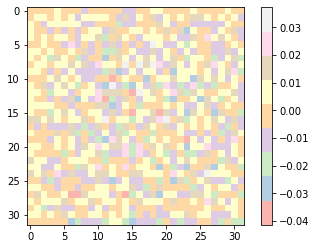

In [51]:
plt.imshow(generated_image[0, :, :, 0], cmap='Pastel1')
plt.colorbar()
plt.show()

생성자의 출력 규격에 맞는, -1 과 1 사이의 값에서 적당한 노이즈가 생성되었다. 

### 판별자

합성곱 신경망(CNN) 기반의 이미지 분류기.
가짜 이미지와 진짜 이미지를 입력받아서 각 이미지 별로 '진짜라고 판단하는 정도' 값을 출력해야한다.

생성자와 판별자의 주요 차이:
- 판별자가 생성자보다 더 깊은 구조를 가짐으로써 복잡한 특성을 더 잘 파악할 수 있도록 설계한다.
- 데이터의 흐름 방향
    - 생성자: 저차원(노이즈 벡터) -> 고차원(이미지)
    - 판별자: 고차원(이미지) -> 저차원(단일 확률값)
- 아키텍처 구조
    - 생성자: 점진적 업샘플링(확장) 구조 (4×4 → 32×32)
    - 판별자: 점진적 다운샘플링(축소) 구조 (32×32 → 1)
- 채널 수 변화
    - 생성자: 많은 채널에서 적은 채널로 (256→128→64→32→3)
    - 판별자: 적은 채널에서 많은 채널로 (3→32→64→128→256)
- 활성화 함수
    - 생성자: 마지막 레이어에 tanh 사용 (출력 범위: -1~1)
    - 판별자: 마지막 레이어에 sigmoid 사용 (출력 범위: 0~1)
- Dropout의 활용
    - 생성자: 일반적으로 Dropout을 사용하지 않음
    - 판별자: 과적합 방지를 위해 Dropout 사용 (0.3)
- 학습 안정성
    - 생성자는 판별자에 비해 학습이 어려울 수 있어, 배치 정규화가 더 중요
    - 판별자는 상대적으로 빠르게 학습되어 생성자보다 "우세"해질 수 있으므로, Dropout으로 학습 속도를 조절

모델 설명:
1. 입력: 32x32x3 크기의 RGB 이미지
2. 여러 합성곱 레이어를 통해 점진적으로 이미지의 공간 차원을 축소한다
3. 각 레이어 이후에 LeakyReLU 활성화 함수를 사용한다
4. 과적합 방지를 위해 Dropout 레이어 적용
5. BatchNormalization으로 학습 안정성을 높이기
6. 마지막에 특성 맵을 평탄화하고, 단일 출력 뉴런을 통해 입력 이미지가 진짜인지 가짜인지 판별
7. Sigmoid 활성화 함수를 사용하여 0(가짜)과 1(진짜) 사이의 확률값 출력

Stride 사용:
- DCGAN 의 설계 원칙 중 하나로, 풀링 레이어를 사용하지 않는 것이 특징
- 풀링 대신 스트라이드 합성곱을 사용해 다운샘플링을 한다.
- 스트라이드만으로 크기를 축소하므로 패딩은 'same'을 사용, 모서리 정보의 손실을 최소화한다.



In [58]:
def make_discriminator_model(input_shape=(32,32,3)):
    '''
    DCGAN 판별자 모델 구현 함수
    
    Args:
        input_shape: 입력 이미지의 형태 (기본값: (32,32,3))
        
    Returns:
        model: 케라스 시퀀셜 모델 객체
    '''
    # step 0
    model = tf.keras.Sequential()
    
    # step 1: 첫번째 합성곱 레이어
    model.add(layers.Conv2D(32, (4,4), strides=(2,2), padding='same', input_shape=input_shape))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # step 2: 두번째 합성곱 레이어; 필터 크기 4x4를 64개 사용
    model.add(layers.Conv2D(64,(4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # step 3: 세번째 합성곱 레이어
    model.add(layers.Conv2D(128,(4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # step 4: 네번째 합성곱 레이어
    model.add(layers.Conv2D(256,(4,4), strides=(2,2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # step 5: 완전 연결 레이어로 변환
    model.add(layers.Flatten())
    
    # step 6: 출력 레이어; 진짜/가짜 이미지 판별 (1=진짜, 0=가짜)
    model.add(layers.Dense(1))
    
    return model

In [59]:
discriminator = make_discriminator_model()

discriminator.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 16, 16, 32)        1568      
_________________________________________________________________
leaky_re_lu_8 (LeakyReLU)    (None, 16, 16, 32)        0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 8, 8, 64)          32832     
_________________________________________________________________
batch_normalization_7 (Batch (None, 8, 8, 64)          256       
_________________________________________________________________
leaky_re_lu_9 (LeakyReLU)    (None, 8, 8, 64)          0         
_________________________________________________________________
dropout_5 (Dropout)          (None, 8, 8, 64)         

In [60]:
# 텐서형태로 출력됨
decision = discriminator(generated_image, training=False)
print (decision)

tf.Tensor([[2.0745312e-05]], shape=(1, 1), dtype=float32)


### 모델 학습: 손실함수와 최적화 함수

from_logits 파라미터:
- True: 입력값이 활성화 함수를 통과하기 전의 원시 로짓(logit) 값임을 의미
- False: 입력값이 이미 활성화 함수(예: sigmoid)를 통과한 확률값임을 의미
- 잘못 설정하면 수치적 안정성 문제와 부정확한 손실 계산이 발생할 수 있다.
- 모델 구조와 손실 함수의 from_logits 파라미터를 일치시키는 것이 중요하다.  

    Descriminator 모델에서: 
    - 마지막 레이어에 sigmoid를 사용했다면 → from_logits=**False**
    - 마지막 레이어에 활성화 함수가 없다면 → from_logits=**True**

In [61]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### generator_loss

In [63]:
# cross_entropy(tf.ones_like(fake_output), fake_output) 값은 
# fake_output이 (Real Image를 의미하는) 1에 가까울수록 작은 값을 가진다.

def generator_loss(fake_output):
    '''
    생성자 손실 함수 - 생성된 이미지가 진짜처럼 보이도록 학습
    
    Args:
        fake_output: 판별자가 생성된 이미지에 대해 출력한 값
    
    Returns:
        loss: 생성자 손실값
    '''
    # 생성자는 판별자가 생성된 이미지를 진짜(1)로 분류하길 원함
    return cross_entropy(tf.ones_like(fake_output), fake_output)

### discriminator_loss

In [64]:
def discriminator_loss(real_output, fake_output):
    """
    판별자 손실 함수 - 진짜와 가짜 이미지를 정확히 분류하도록 학습
    
    Args:
        real_output: 판별자가 진짜 이미지에 대해 출력한 값
        fake_output: 판별자가 생성된 이미지에 대해 출력한 값
    
    Returns:
        total_loss: 판별자 손실값
    """
    # 진짜 이미지에 대해서는 1에 가깝게
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    
    # 가짜 이미지에 대해서는 0에 가깝게
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    
    # 전체 손실은 두 손실의 합
    total_loss = real_loss + fake_loss
    
    return total_loss

### discriminator_accuracy

In [65]:
def discriminator_accuracy(real_output, fake_output):
    """
    판별자의 분류 정확도 계산
    
    Args:
        real_output: 판별자가 진짜 이미지에 대해 출력한 값
        fake_output: 판별자가 생성된 이미지에 대해 출력한 값
    
    Returns:
        real_accuracy: 진짜 이미지 분류 정확도
        fake_accuracy: 가짜 이미지 분류 정확도
    """
    # 진짜 이미지에 대한 정확도 (0.5를 기준으로 분류)
    real_accuracy = tf.reduce_mean(tf.cast(tf.math.greater_equal(real_output, tf.constant([0.5])), tf.float32))
    
    # 가짜 이미지에 대한 정확도 (0.5를 기준으로 분류)
    fake_accuracy = tf.reduce_mean(tf.cast(tf.math.less(fake_output, tf.constant([0.5])), tf.float32))
    
    return real_accuracy, fake_accuracy

### 최적화 함수 (optimizer)

Adam 최적화 기법

- 감별자와 생성자는 따로 훈련되기 때문에, 감별자와 생성자의 옵티마이저는 따로 설정해주어야 한다.


또한, 매 학습마다 진행 상황 확인을 위해 생성자가 생성한 샘플을 확인한다.
- 샘플은 한 번에 16장을 생성하도록 하겠습니다.
- 생성할 샘플은 매번 같은 노이즈로 생성해야 그에 대한 진전 과정을 확인할 수 있으므로, 고정된 seed 노이즈를 만들어두어야 합니다. -> GIF 애니메이션에서 진전 내용을 시각화하기 쉽다.
- 즉, 100차원의 노이즈를 총 16개, (16, 100) 형상의 벡터를 만들어 두도록 하겠습니다.

훈련 루프는 생성자가 입력으로 랜덤시드를 받는 것으로부터 시작한다.
그 시드값을 이용해 이미지를 생성한다.
감별자를 사용해 훈련 세트에서 갖고온 진짜 이미지와 생성자가 생성한 가짜 이미지를 분류한다. 
각 모델의 손실을 계산하고, 그래디언트를 사용해 생성자와 감별자를 업데이트한다. 

In [66]:
# 최적화기 정의
def define_optimizers(learning_rate=0.0002, beta_1=0.5):
    """
    생성자와 판별자를 위한 최적화기 정의
    
    Args:
        learning_rate: 학습률 (기본값: 0.0002)
        beta_1: Adam 최적화기의 첫 번째 모멘텀 계수 (기본값: 0.5)
    
    Returns:
        generator_optimizer: 생성자 최적화기
        discriminator_optimizer: 판별자 최적화기
    """
    # DCGAN 논문에서 권장하는 Adam 파라미터: lr=0.0002, beta_1=0.5
    generator_optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate, beta_1=beta_1
    )
    
    discriminator_optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate, beta_1=beta_1
    )
    
    return generator_optimizer, discriminator_optimizer

# 결과값을 각각의 객체에 담기
generator_optimizer, discriminator_optimizer = define_optimizers()

### 훈련과정 설계

In [67]:
# 상수 정의
EPOCHS = 50

# 시각화용 - 고정된 시드 생성
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])
seed.shape

TensorShape([16, 100])

#### tf.function 차이 비교

하나의 미니 배치 당 진행할 train_step 함수 만들기  

@tf.function 데코레이터:  
    - Compiles a function into a callable TensorFlow graph  
    - 이 데코레이터가 사용된 함수에 입력된 입력은 Tensorflow의 graph 노드가 될 수 있는 타입으로 자동 변환된다. 
 

### 훈련 스텝 함수

In [68]:
# `tf.function`데코레이터는 함수를 "컴파일"한다.

@tf.function
def train_step(images, 
               generator, 
               discriminator, 
               generator_optimizer, 
               discriminator_optimizer, 
               batch_size, 
               noise_dim): 
     """
    1개 미니배치의 훈련 과정을 처리하는 함수
    
    Args:
        images: 실제 이미지 배치
        generator: 생성자 모델
        discriminator: 판별자 모델
        generator_optimizer: 생성자 최적화기
        discriminator_optimizer: 판별자 최적화기
        batch_size: 배치 크기
        noise_dim: 노이즈 벡터 차원
    
    Returns:
        gen_loss: 생성자 손실
        disc_loss: 판별자 손실
        real_accuracy: 실제 이미지 판별 정확도
        fake_accuracy: 생성된 이미지 판별 정확도
    """
    # 생성자 입력 노이즈
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    
    # 모든 forward pass와 loss 계산은 GradientTape 블록 안에 있어야 함
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape: 
        generated_images = generator(noise, training=True) # generated_images 생성
    
        # discriminator 판별
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # loss 계산
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # accuracy 계산
    # accuracy 계산은 gradient와 관련이 없으므로 GradientTape 블록 밖에 있어도 됨
    real_accuracy, fake_accuracy = discriminator_accuracy(real_output, fake_output)
    
    # gradient 계산
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # 최적화기 적용
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    
    # 리턴값
    return gen_loss, disc_loss, real_accuracy, fake_accuracy 

### 생성 이미지 시각화 & 저장

한 단계씩 학습하는 train_step과 함께 일정 간격으로 학습 현황을 볼 수 있는 샘플 생성

In [72]:
# 고정된 seed에 대한 결과물이 얼마나 나아지고 있는지 확인

def generate_and_save_images(generator, epoch, it, sample_seeds):
    """
    고정된 시드를 사용하여 생성된 이미지를 시각화하고 저장
    
    Args:
        generator: 생성자 모델
        epoch: 현재 에포크 번호
        it: 
        sample_seeds: 고정된 노이즈 시드
    """
    # training = False: 배치정규화를 포함해 모든 층들이 추론 모드로 실행된다.
    predictions = generator(sample_seeds, training=False)
    
    fig = plt.figure(figsize=(4,4))
    
    for i in range(predictions.shape[0]):
        plt.subplot(4,4, i+1)
        # tanh 출력을 0~1 범위로 변환
        img = (predictions[i, :, :, :] +1) /2.0
        plt.imshow(img)
        plt.axis('off')
        
    # plt.savefig(): plt로 출력한 이미지를 파일로 저장     
    plt.savefig('{}/aiffel/dcgan_newimage/fashion/generated_samples/sample_epoch_{:04d}_iter_{:03d}.png'
                    .format(os.getenv('HOME'), epoch, it))

    plt.show()

### 훈련 히스토리 그래프 시각화 

In [71]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15,6 # 차트의 기본 크기 지정

def draw_train_history(history, epoch):
    """
    훈련 히스토리를 그래프로 시각화
    
    Args:
        history: 훈련 과정에서 기록된 손실 및 정확도 히스토리
        epoch: 훈련 에포크
    """
    # summarize history for loss
    plt.subplot(211)
    plt.plot(history['gen_loss'])
    plt.plot(history['disc_loss'])
    plt.title('Model loss')
    plt.ylabel('loss')
    plt.xlabel('batch iters')
    plt.legend(['gen_loss', 'disc_loss'], loc='upper left')
    
    # summarize history for accuracy
    plt.subplot(212)
    plt.plot(history['fake_accuracy'])
    plt.plot(history['real_accuracy'])
    plt.title('Discriminator accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('batch iters')
    plt.legend(['fake_accuracy','real_accuracy'], loc='upper left')
    
    # training_history 디렉토리에 epoch별로 그래프를 이미지 파일로 저장한다.
    plt.savefig('{}/aiffel/dcgan_newimage/fashion/training_history/train_history_{:04d}.png'
                    .format(os.getenv('HOME'), epoch))
    plt.show()

### model save - checkpoint

checkpoint에는 optimizer와 생성자, 판별자를 모두 넣어 저장한다.
생성자와 판별자가 학습한 모델 가중치를 저장하는 것.

In [70]:
import os

checkpoint_dir = os.getenv('HOME')+'/aiffel/dcgan_newimage/fashion/training_checkpoints'

checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

### 훈련 함수

In [73]:
def train(dataset, epochs, save_every):
    """
    GAN 모델 훈련 함수
    
    Args:
        dataset: 훈련 데이터셋
        epochs: 총 에포크 수
        save_every: 모델 저장 주기 (에포크)
    """
    start = time.time()
    history = {'gen_loss':[], 'disc_loss':[], 'real_accuracy':[], 'fake_accuracy':[]}
    
    for epoch in range(epochs):
        epoch_start = time.time()
        for it, image_batch in enumerate(dataset):
            gen_loss, disc_loss, real_accuracy, fake_accuracy = train_step(image_batch)
            history['gen_loss'].append(gen_loss)
            history['disc_loss'].append(disc_loss)
            history['real_accuracy'].append(real_accuracy)
            history['fake_accuracy'].append(fake_accuracy)
            
            # GIF를 위한 이미지 생성
            if it % 50 == 0:
                display.clear_output(wait=True)
                generate_and_save_images(generator, 
                                         epoch+1, 
                                         it+1, 
                                         seed)
                print(f'Epoch {epoch+1} | iter {it+1}')
                print(f'Time for epoch {epoch+1} : {int(time.time()-epoch_start)} sec')
            
            # save_every에 설정한 에포크가 지날 때마다 모델 저장
            if (epoch + 1) % save_every == 0:
                checkpoint.save(file_prefix=checkpoint_prefix)
            
            # 마지막 에포크가 끝난 수 생성
            display.clear_output(wait=True)
            generate_and_save_images(generator, 
                                     epochs, 
                                     it, 
                                     seed)
            
            # 에포크 소요 시간 출력
            print(f'Time for epoch {epoch+1} is {int(time.time()-start)} sec')
            
            
            draw_train_history(history, epoch)
            
                

In [74]:
save_every = 15
EPOCHS = 50

# 사용가능한 GPU 디바이스 확인
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

위에서 정의한 train() 메서드를 생성자와 감별자를 **동시에** 훈련하기 위해 호출한다.

생성자와 감별자가 서로 제압하지 않는 것이 중요!
학습률이 비슷하면 한쪽이 우세해질 수 있음

훈련 초반부에 생성되는 이미지는 랜덤한 노이즈에서 훈련이 진행될수록, 진짜처럼 보일 것이다.

#### 훈련 모델; 체크포인트 로드 & 재시작 코드

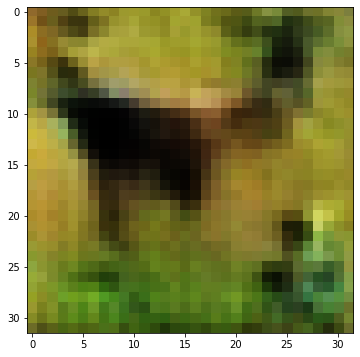

In [122]:
checkpoint_dir = os.getenv('HOME')+'/aiffel/dcgan_newimage/cifar10/training_checkpoints'

latest = tf.train.latest_checkpoint(checkpoint_dir)
checkpoint.restore(latest)

generator = checkpoint.generator
discriminator = checkpoint.discriminator

# 로드한 모델이 정상적으로 이미지를 생성하는지 확인해 봅니다. 
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

np_generated = generated_image.numpy()
np_generated = (np_generated * 127.5) + 127.5   # reverse of normalization
np_generated = np_generated.astype(int)
plt.imshow(np_generated[0])
plt.show()  # 정상적으로 모델이 로드되었다면 랜덤 이미지가 아니라 CIFAR-10 이미지가 그려질 것입니다.

## 모델 학습 시~작! 

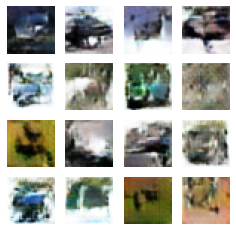

Time for epoch 50 is 14294 sec


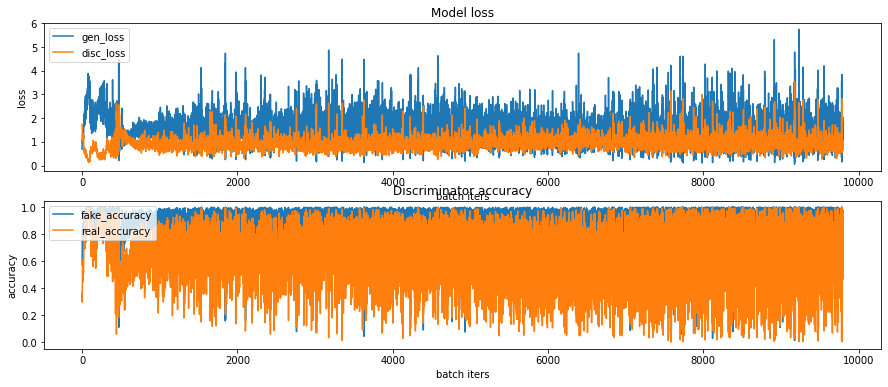

CPU times: user 4h 29min, sys: 50min 9s, total: 5h 19min 10s
Wall time: 3h 58min 15s


In [75]:
%%time
train(train_dataset, EPOCHS, save_every)

# 학습과정의 loss, accuracy 그래프 이미지 파일이 
# ~/aiffel/dcgan_newimage/fashion/training_history 경로에 생성되고 있다. 


### 학습 과정 시각화

imageio 라이브러리를 활용해 학습 과정중 생성된 이미지들을 합쳐 GIF로 생성해보자.
- imageio.get_writer를 활용해 파일을 열고
- append_data로 하나씩 이미지를 붙여나가는 방식

In [77]:
dcgan_gif = os.getenv('HOME')+'/aiffel/dcgan_newimage/cifar10/cifar10_dcgan.gif'

with imageio.get_writer(dcgan_gif, mode='I') as writer:
    filenames = glob.glob('{}/aiffel/dcgan_newimage/cifar10/generated_samples/sample*.png'.format(os.getenv('HOME')))
    filenames = sorted(filenames)
    last = -1
    for i, filename in enumerate(filenames):
        frame = 2*(i**0.5)
        if round(frame) > round(last):
            last = frame
        else:
            continue
        image = imageio.imread(filename)
        writer.append_data(image)
    image=imageio.imread(filename)
    writer.append_data(image)
    
!ls -l ~/aiffel/dcgan_newimage/cifar10/cifar10_dcgan.gif

-rw-r--r-- 1 root root 29822 Apr 17 11:50 /aiffel/aiffel/dcgan_newimage/cifar10/cifar10_dcgan.gif
